
# **N-Grams in NLP — In-Depth Explanation and Essential Codes**

N-grams are a technique in Natural Language Processing (NLP) used to capture **sequences of words** instead of single words.

In Bag of Words, the order of words is ignored.  
N-grams help capture **local word order and context**.

Types of N-grams:

- **Unigram** → single word  
- **Bigram** → two consecutive words  
- **Trigram** → three consecutive words  
- **N-gram** → sequence of N words



# **1. Import Required Libraries**


In [89]:

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer



# **2. Create Sample Text Dataset**


In [90]:

data = pd.DataFrame({
    "text":[
        "I love machine learning",
        "Machine learning is powerful",
        "I love NLP",
        "NLP is amazing"
    ]
})

data

,text
0,I love machine learning
1,Machine learning is powerful
2,I love NLP
3,NLP is amazing



# **3. Unigrams (Single Words)**

Unigram considers each word independently.


In [91]:

vectorizer = CountVectorizer(ngram_range=(1,1))
#count vectorizer is used to convert a collection of text documents to a matrix of token counts. It creates a sparse matrix where each row represents a document and each column represents a unique word in the corpus. The value in each cell is the count of the corresponding word in the document.
#here (1,1) means we are only considering unigrams (single words) as features. If we wanted to include bigrams (pairs of consecutive words), we could set ngram_range=(1,2).
X = vectorizer.fit_transform(data["text"])

print(vectorizer.get_feature_names_out())
print(X.toarray())


['amazing' 'is' 'learning' 'love' 'machine' 'nlp' 'powerful']
[[0 0 1 1 1 0 0]
 [0 1 1 0 1 0 1]
 [0 0 0 1 0 1 0]
 [1 1 0 0 0 1 0]]



# **4. Bigrams (Two Word Sequences)**

Bigram captures pairs of consecutive words.

Example:

"I love machine learning"

Bigrams:

- I love  
- love machine  
- machine learning


In [92]:

vectorizer = CountVectorizer(ngram_range=(2,2))
#here (2,2) means we are only considering bigrams (pairs of consecutive words) as features. If we wanted to include unigrams (single words) as well, we could set ngram_range=(1,2).
X = vectorizer.fit_transform(data["text"])

print(vectorizer.get_feature_names_out())
print(X.toarray())


['is amazing' 'is powerful' 'learning is' 'love machine' 'love nlp'
 'machine learning' 'nlp is']
[[0 0 0 1 0 1 0]
 [0 1 1 0 0 1 0]
 [0 0 0 0 1 0 0]
 [1 0 0 0 0 0 1]]



# **5. Trigrams (Three Word Sequences)**

Trigrams capture three-word combinations.


In [93]:

vectorizer = CountVectorizer(ngram_range=(3,3))
#here (3,3) means we are only considering trigrams (triplets of consecutive words) as features. If we wanted to include unigrams and bigrams as well, we could set ngram_range=(1,3).

X = vectorizer.fit_transform(data["text"])

print(vectorizer.get_feature_names_out())
print(X.toarray())
print(X)

['learning is powerful' 'love machine learning' 'machine learning is'
 'nlp is amazing']
[[0 1 0 0]
 [1 0 1 0]
 [0 0 0 0]
 [0 0 0 1]]
  (0, 1)	1
  (1, 2)	1
  (1, 0)	1
  (3, 3)	1


[[0 1 0 0]
 [1 0 1 0]
 [0 0 0 0]
 [0 0 0 1]]

Rows = sentences
Columns = trigrams


# **6. Combining Unigrams and Bigrams**

Often we use both together:

- Single words
- Word pairs


In [94]:

vectorizer = CountVectorizer(ngram_range=(1,2))
#here (1,2) means we are considering both unigrams (single words) and bigrams (pairs of consecutive words) as features. This allows us to capture more context from the text data, as bigrams can provide information about word combinations that may be important for understanding the meaning of the text.

X = vectorizer.fit_transform(data["text"])

print(vectorizer.get_feature_names_out())
print(X.toarray())


['amazing' 'is' 'is amazing' 'is powerful' 'learning' 'learning is' 'love'
 'love machine' 'love nlp' 'machine' 'machine learning' 'nlp' 'nlp is'
 'powerful']
[[0 0 0 0 1 0 1 1 0 1 1 0 0 0]
 [0 1 0 1 1 1 0 0 0 1 1 0 0 1]
 [0 0 0 0 0 0 1 0 1 0 0 1 0 0]
 [1 1 1 0 0 0 0 0 0 0 0 1 1 0]]


**CountVectorizer (ngram_range = (1,2)) – Short Note**

This code converts text into numerical features using both **unigrams (single words)** and **bigrams (pairs of consecutive words)**.

* `ngram_range=(1,2)` → includes words like *"machine"* and phrases like *"machine learning"*
* `fit_transform()` → learns all unique words/phrases (vocabulary) and converts text into a matrix
* Each **row** represents a sentence
* Each **column** represents a word or bigram
* Values (0,1,2...) show how many times that word/bigram appears in the sentence

**Purpose:**
To capture both individual word meaning and word combinations (context), which helps improve model performance.



# **7. N-Grams with TF-IDF**


In [95]:

tfidf = TfidfVectorizer(ngram_range=(1,2))

X = tfidf.fit_transform(data["text"])

print(tfidf.get_feature_names_out())
print(X.toarray())
print(X)

['amazing' 'is' 'is amazing' 'is powerful' 'learning' 'learning is' 'love'
 'love machine' 'love nlp' 'machine' 'machine learning' 'nlp' 'nlp is'
 'powerful']
[[0.         0.         0.         0.         0.4222466  0.
  0.4222466  0.53556627 0.         0.4222466  0.4222466  0.
  0.         0.        ]
 [0.         0.3365971  0.         0.42693074 0.3365971  0.42693074
  0.         0.         0.         0.3365971  0.3365971  0.
  0.         0.42693074]
 [0.         0.         0.         0.         0.         0.
  0.52640543 0.         0.66767854 0.         0.         0.52640543
  0.         0.        ]
 [0.48546061 0.38274272 0.48546061 0.         0.         0.
  0.         0.         0.         0.         0.         0.38274272
  0.48546061 0.        ]]
  (0, 10)	0.4222466008506261
  (0, 7)	0.5355662725381126
  (0, 4)	0.4222466008506261
  (0, 9)	0.4222466008506261
  (0, 6)	0.4222466008506261
  (1, 3)	0.42693074020919825
  (1, 5)	0.42693074020919825
  (1, 13)	0.42693074020919825
  (1, 1

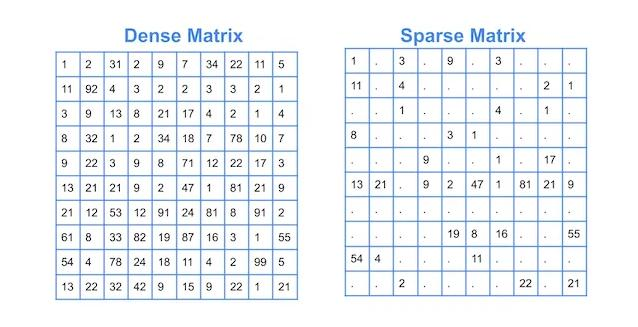

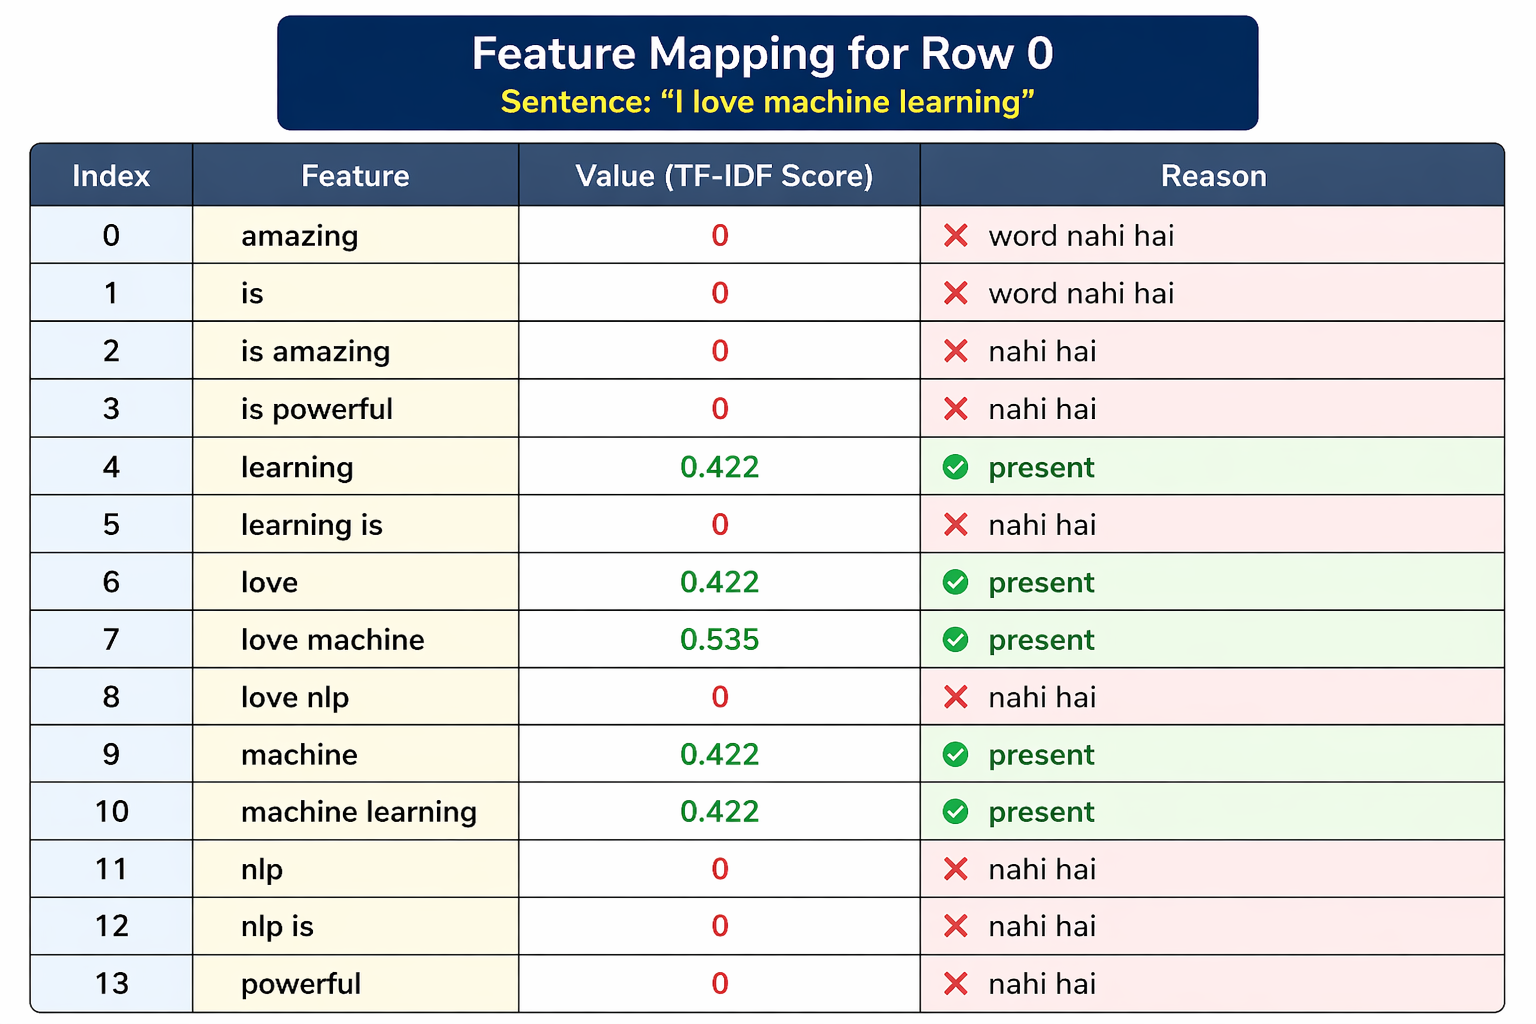

[0,0,0,0,0.422,0,0.422,0.535,0,0.422,0.422,0,0,0]

(0,4)  0.422   → learning  
(0,6)  0.422   → love  
(0,7)  0.535   → love machine  
(0,9)  0.422   → machine  
(0,10) 0.422   → machine learning  

**Rows and Columns in TF-IDF (Short Note)**

* Each **row** represents one sentence (document).
  Example:
  Row 0 → "I love machine learning"
  Row 1 → "Machine learning is powerful"

* Each **column** represents a **feature**, i.e., a word (unigram) or word pair (bigram).
  Example:
  Columns → "love", "machine", "machine learning", "is powerful", etc.

* The **value inside the table** (cell) shows the **TF-IDF score**, which indicates how important that word/phrase is in that sentence.

**Summary:**
Row = sentence
Column = word/phrase
Value = importance of that word in that sentence



# **8. Limiting N-Gram Features**

Large datasets can produce huge vocabularies.  
We can limit features using `max_features`.


In [96]:

vectorizer = CountVectorizer(ngram_range=(1,2), max_features=10)

X = vectorizer.fit_transform(data["text"])

print(vectorizer.get_feature_names_out())


['amazing' 'is' 'is amazing' 'is powerful' 'learning' 'learning is' 'love'
 'machine' 'machine learning' 'nlp']



# **9. N-Grams with Machine Learning Model**


In [97]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

data["label"] = [1,1,0,0]

X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = CountVectorizer(ngram_range=(1,2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression()
model.fit(X_train_vec, y_train)

predictions = model.predict(X_test_vec)

predictions


array([0], dtype=int64)


# **Advantages of N-Grams**

- Captures local word order
- Improves text classification
- Helps capture phrases



# **Limitations of N-Grams**

- Vocabulary size grows quickly
- High dimensional sparse matrices
- Computationally expensive



# **Summary**

N-Grams help capture **word sequences and context**.

Pipeline:

Raw Text  
↓  
Tokenization  
↓  
Generate N-Grams  
↓  
Vectorization (BoW / TF-IDF)  
↓  
Machine Learning Model
